In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#Ипортирую LabelEncording
from sklearn.preprocessing import LabelEncoder
#Для разделение данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
#Для приведение выборки к одному масштабу
from sklearn.preprocessing import StandardScaler
#Для KNN
from sklearn.neighbors import KNeighborsClassifier
#Для точностти
from sklearn.metrics import accuracy_score
#Для кросс валидации
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score, f1_score, recall_score, confusion_matrix


Я выбрал датасет iris species имеет он 
4 признака
3 класса 



* **`Id`** — Идентификатор (порядковый номер цветка от 1 до 150).
* **`SepalLengthCm`** — Длина чашелистика (в сантиметрах).
* **`SepalWidthCm`** — Ширина чашелистика (в сантиметрах).
* **`PetalLengthCm`** — Длина лепестка (в сантиметрах).
* **`PetalWidthCm`** — Ширина лепестка (в сантиметрах).
* **`Species`** — Вид ириса наша целевая переменная

### Первичный анализ данных

In [3]:
df = pd.read_csv('iris.csv')
#Удаляю колонку id из-за ненадабности
df = df.drop('Id', axis = 1)

print('Размер датасета', df.shape)
display(df.head(5))
display(df.tail(5))

print('Типы признаков')
display(df.info())

print('Основная статистика')
display(df.describe())

print('Наличие пропусков')
display(df.isnull().sum())

print('Дубликаты')
display(df.duplicated().sum())
df = df.drop_duplicates()

print('Распределение классов')
display(df['Species'].value_counts())

# Проверим дубликаты в фичях то есть если ли такая ситуация что значения фич одинаковые а целевые у них разные
display(df.columns)
fearures = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
conflicts = df[df.duplicated(subset = fearures, keep = False)]
print('Проверяем')
display(conflicts.sort_values(by=fearures))

print('Размер')
display(df.shape)
df.size











Размер датасета (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Типы признаков
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

...

Проверяем


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species


Размер


(147, 5)

735

### Посмотрим на выбросы

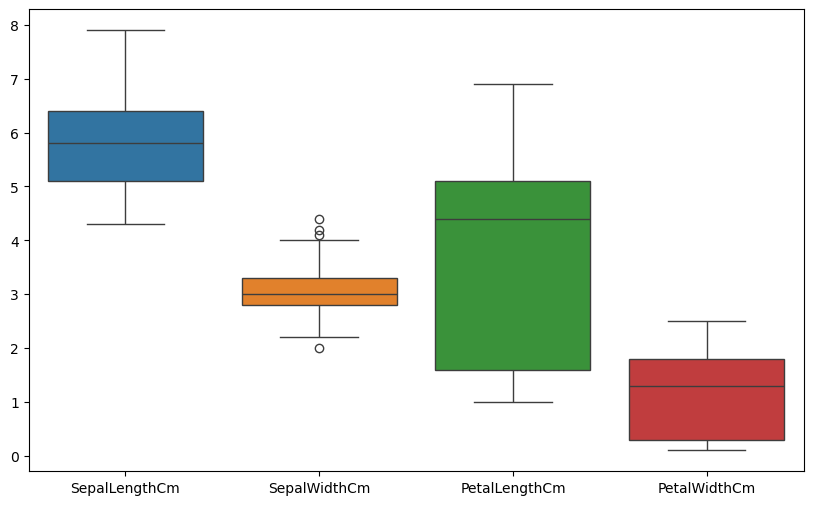

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('Species', axis=1))
plt.show()

#### Выводы
 * Итоговый размер 147 x 5 
 * типы признаков 4 float64 1 object 
 * распредление классов у нас характиризуется нормальным
 *  пропусков нет 
 * дубликаты удалены
 * выбросов нет
 * статистика впорядке
 * категориальных фич не имеется

### Подготовка данных

#### Масштабирование признаков

In [5]:
# Для предотвашения ошибки на всякий случай переду целевую в LabelEncording
y = df['Species']
le = LabelEncoder()
y = le.fit_transform(y)
#Масштабировние признаков
X = df.drop('Species', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled)
columns=X.columns
display(X_scaled)


array([[-0.91550949,  1.0199714 , -1.35773692, -1.33570001],
       [-1.15755966, -0.12808217, -1.35773692, -1.33570001],
       [-1.39960983,  0.33113926, -1.41477817, -1.33570001],
       [-1.52063491,  0.10152855, -1.30069567, -1.33570001],
       [-1.03653457,  1.24958212, -1.35773692, -1.33570001],
       [-0.55243423,  1.93841426, -1.18661318, -1.07090176],
       [-1.52063491,  0.79036069, -1.35773692, -1.20330089],
       [-1.03653457,  0.79036069, -1.30069567, -1.33570001],
       [-1.76268509, -0.35769288, -1.35773692, -1.33570001],
       [-1.15755966,  0.10152855, -1.30069567, -1.46809914],
       [-0.55243423,  1.47919283, -1.30069567, -1.33570001],
       [-1.27858474,  0.79036069, -1.24365442, -1.33570001],
       [-1.27858474, -0.12808217, -1.35773692, -1.46809914],
       [-1.88371017, -0.12808217, -1.52886066, -1.46809914],
       [-0.06833389,  2.16802498, -1.47181942, -1.33570001],
       [-0.18935898,  3.08646783, -1.30069567, -1.07090176],
       [-0.55243423,  1.

#### Разделение на train/test


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
        

In [7]:
metrics = ['minkowski', 'manhattan', 'euclidean']
weights = ['uniform', 'distance']
results = []
for k in range(3, 50, 2):
    for w in weights:
        for m in metrics:
            knn = KNeighborsClassifier(n_neighbors=k, weights=w, metric=m)
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)
            score = accuracy_score(y_test, y_pred)
            results.append({'K': k, 'Метрика': m, 'Веса': w, 'Точность': score})



display(pd.DataFrame(results))
results_df = pd.DataFrame(results)
top_df = results_df.sort_values(by='Точность', ascending=False)
top_df.head(10)

,K,Метрика,Веса,Точность
0,3,minkowski,uniform,0.933333
1,3,manhattan,uniform,0.933333
2,3,euclidean,uniform,0.933333
3,3,minkowski,distance,0.933333
4,3,manhattan,distance,0.933333
...,...,...,...,...
139,49,manhattan,uniform,0.933333
140,49,euclidean,uniform,0.866667
141,49,minkowski,distance,0.966667
142,49,manhattan,distance,0.966667


,K,Метрика,Веса,Точность
72,27,minkowski,uniform,0.966667
78,29,minkowski,uniform,0.966667
89,31,euclidean,distance,0.966667
88,31,manhattan,distance,0.966667
87,31,minkowski,distance,0.966667
86,31,euclidean,uniform,0.966667
85,31,manhattan,uniform,0.966667
84,31,minkowski,uniform,0.966667
83,29,euclidean,distance,0.966667
81,29,minkowski,distance,0.966667


#### Лучшие рещультаты показал минковский


### Подбор гиперпараметров

In [8]:
#gridsearchSV
param_grid = {
    'n_neighbors': range(3, 50, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring= 'accuracy',
    n_jobs= -1,
    verbose=1,
    

)

grid.fit(X_train, y_train)
print(grid.best_score_)
results = pd.DataFrame(grid.cv_results_)
print('gridsearchSV')
display(results.sort_values(ascending=False, by='mean_test_score').head(5))

randsize = RandomizedSearchCV(
    estimator=knn,
    param_distributions = param_grid,
    n_iter= 30,
    cv = 5,


)
print('RandomizedSearchCV')
randsize.fit(X_train, y_train)
results_ran = pd.DataFrame(randsize.cv_results_)
display(results_ran.sort_values(ascending=False, by='mean_test_score').head(5))




Fitting 5 folds for each of 144 candidates, totalling 720 fits
0.9829710144927537
gridsearchSV


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
103,0.000295,0.000007,0.000673,0.000127,minkowski,9,distance,"{'metric': 'minkowski', 'n_neighbors': 9, 'wei...",1.0,0.958333,0.956522,1.0,1.000000,0.982971,0.020864,1
7,0.000471,0.000132,0.000895,0.000235,euclidean,9,distance,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",1.0,0.958333,0.956522,1.0,1.000000,0.982971,0.020864,1
102,0.000430,0.000119,0.001137,0.000228,minkowski,9,uniform,"{'metric': 'minkowski', 'n_neighbors': 9, 'wei...",1.0,0.958333,0.956522,1.0,1.000000,0.982971,0.020864,1
6,0.000431,0.000104,0.001211,0.000222,euclidean,9,uniform,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",1.0,0.958333,0.956522,1.0,1.000000,0.982971,0.020864,1
54,0.000498,0.000109,0.001333,0.000171,manhattan,9,uniform,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",1.0,1.000000,0.956522,1.0,0.956522,0.982609,0.021300,5


RandomizedSearchCV


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_weights,param_n_neighbors,param_metric,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
28,0.000329,0.000037,0.000859,0.000104,uniform,9,euclidean,"{'weights': 'uniform', 'n_neighbors': 9, 'metr...",1.000000,0.958333,0.956522,1.0,1.000000,0.982971,0.020864,1
2,0.000186,0.000004,0.000324,0.000023,distance,3,minkowski,"{'weights': 'distance', 'n_neighbors': 3, 'met...",0.958333,0.958333,0.956522,1.0,1.000000,0.974638,0.020719,2
1,0.000200,0.000012,0.000599,0.000164,uniform,7,manhattan,"{'weights': 'uniform', 'n_neighbors': 7, 'metr...",1.000000,1.000000,0.913043,1.0,0.956522,0.973913,0.034783,3
29,0.000258,0.000059,0.000471,0.000101,distance,19,euclidean,"{'weights': 'distance', 'n_neighbors': 19, 'me...",1.000000,0.958333,0.913043,1.0,0.956522,0.965580,0.032447,4
10,0.000188,0.000004,0.000358,0.000014,distance,23,euclidean,"{'weights': 'distance', 'n_neighbors': 23, 'me...",1.000000,0.958333,0.913043,1.0,0.956522,0.965580,0.032447,4


#### Исследовался диапазон от 3 до 49. Анализ показал, что слишком маленькие $k$ (например, 3) делают модель нестабильной, а слишком большие (от 31 и выше) приводят к излишнему усреднению. Оптимальным оказался баланс в районе $k=9$.
#### Я сравнили Евклидово (euclidean), Манхэттенское (manhattan) расстояние и метрику Минковского (minkowski). На данных они показали близкие результаты, однако Евклидово/Минковского расстояния оказались чуть более точными в разделении пограничных объектов.

In [18]:
#precision_score
print('precision_score')
predsxre = precision_score(y_test, y_pred, average = 'macro')
display(predsxre)

#confusion_matrix
conmat = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conmat))

#recall_score
rescore = recall_score(y_test, y_pred, average='macro')
print('recall_score')
display(rescore)

#f_1
print('f1')
f1 = f1_score(y_test, y_pred, average = 'macro')
display(f1)

precision_score


0.9696969696969697

,0,1,2
0,11,0,0
1,0,10,0
2,0,1,8


recall_score


0.9629629629629629

f1


0.9645191409897292

#### Для исключения проблемы переобучения (overfitting), итоговый тестк модели проводился на тестовых данных, которые алгоритм ранее не видел. Чтобы получить объективную картину, использовалась не только общая точность (Accuracy), но и метрики баланса с макро-усреднением

Accuracy: 0.966

Precision: 0.970 — модель практически не дает ложных срабатываний.

Recall: 0.963 — модель успешно находит почти все объекты нужного класса.

F1-score: 0.965 — подтверждает идеальный баланс алгоритма.

#### Детальный анализ показал, что на 30 тестовых объектах модель ошиблась всего один раз: сорт Iris-setosa она определяет безупречно, а единственный промах случился с цветком Virginica, который алгоритм принял за Versicolor. На самом деле, это не недочет алгоритма, а физическая особенность самих растений — размеры их лепестков сильно пересекаются, образуя на графике общую зону. Поскольку метод k-NN принимает решения исключительно на основе геометрической близости точек, он вполне ожидаемо испытывает трудности именно на нечеткой границе этих сливающихся «облаков» данных.

#### Выводl: Эксперимент доказал, что метод k-NN превосходно подходит для решения данной задачи при условии правильной подготовки данных (масштабирования) и грамотного подбора гиперпараметров. Итоговая модель стабильна, не переобучена и готова к классификации новых объектов.